# Chapter: Feature Metadata and Feature Cards
## Feature Engineering & MLOps

**"Six months later, nobody remembers how a feature was calculated."** This chapter is about
the unglamorous but essential practice of documenting features properly — so that sentence
never has to be said about anything you build.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain why features need documentation, not just code
- Build a simple feature metadata registry (as a DataFrame or dictionary)
- Write a complete "Feature Card" for a real feature
- Identify what information is missing when handed an undocumented feature
- Apply a basic governance question — "am I even allowed to use this?" — before using any
  feature in a new project

## Real-World Problem

You've inherited a churn-prediction project from a colleague who left the company. Buried in
their feature pipeline is a column called `days_since_last_login`. It's clearly useful — but:

- **What does it mean, exactly?** Days since the customer's account was last accessed? Last
  made a purchase? Last opened an email?
- **Where does it come from?** Which raw table, which system?
- **How is it calculated?** As of which snapshot date? Calendar days or business days?
- **When was it last updated?** Is this number fresh, or a stale one-time calculation from a
  year ago?
- **Who owns it?** Who do you ask when something looks wrong?
- **Can you even use it?** Maybe it was flagged in a data governance review as unreliable, or
  restricted for a reason nobody wrote down.

Without documentation, you either have to reverse-engineer the code (slow, error-prone) or ask
around and hope someone remembers (often nobody does). This chapter is about avoiding that
entirely.

## Why Do We Need This Concept?

**Analogy:** imagine buying packaged food with no ingredients label, no expiry date, and no
manufacturer listed. You might still eat it — but you have no way to know if it's safe, fresh,
or right for your diet. A feature without documentation is exactly that: technically usable,
but impossible to trust or reason about responsibly.

**What happens if we skip this?**
- New team members waste days reverse-engineering what a feature means
- Features get reused in contexts where they were never validated (and quietly produce wrong
  results)
- Nobody can answer basic audit/compliance questions like "what data went into this
  prediction, and was it allowed?"
- Stale features silently keep getting used long after they've stopped being maintained or
  updated

## Concept Intuition

Every feature deserves an answer to each of these questions, written down, not just known by
whoever happened to build it:

```
FEATURE: days_since_last_login
   |
   +-- WHAT does it mean?        -> business_definition
   +-- WHERE does it come from?  -> source
   +-- HOW is it calculated?     -> transformation
   +-- WHEN was it last updated? -> freshness
   +-- WHO owns it?              -> owner
   +-- CAN I use it?             -> allowed_for_training
```

A **feature registry** is simply a table with one row per feature, answering all six questions
at once — the same idea as a library's card catalog: you don't need to read every book to know
what's in the library, you just check the card.

## Tiny Manual Example

Let's walk through the six questions above, by hand, for `days_since_last_login` — exactly the
feature from our Business Features chapter.

| Question | Answer |
|---|---|
| **What does it mean?** | Number of calendar days between today's snapshot date and the customer's most recent login to the account. |
| **Where does it come from?** | The `customers` table, specifically the `last_login_date` column. |
| **How is it calculated?** | `(snapshot_date - last_login_date).days` — a simple date subtraction. |
| **When was it last updated?** | Recalculated daily, as of the current snapshot date, whenever the feature pipeline runs. |
| **Who owns it?** | The Customer Analytics team (they own the `customers` table and its login tracking). |
| **Can I use it for prediction?** | Yes — it reflects information genuinely available before any churn decision, so it's safe for a churn model (see the Data Leakage chapter for why that check matters). |

Notice: every one of these answers took ONE sentence to write down. The cost of documenting a
feature is tiny. The cost of NOT documenting it — reverse-engineering it six months later, or
worse, misusing it because nobody knew it was restricted — is much larger.

## Python Implementation

### Step 1 — Build a simple feature registry

A feature registry doesn't need special infrastructure to start — a `DataFrame` (or even a
Python dictionary) is enough to capture the essential metadata for every feature your team
produces.

In [1]:
import pandas as pd

feature_registry = pd.DataFrame([
    {
        "feature_name": "days_since_last_login",
        "description": "Days since the customer's most recent account login",
        "source": "customers.last_login_date",
        "data_type": "integer",
        "transformation": "(snapshot_date - last_login_date).days",
        "owner": "Customer Analytics Team",
        "freshness": "daily",
        "availability_time": "available at prediction time (no future data used)",
        "business_definition": "How long a customer has been disengaged from the platform",
        "allowed_for_training": True,
        "notes": "Safe for churn prediction -- reflects only past behavior",
    },
    {
        "feature_name": "recency_days",
        "description": "Days since the customer's most recent transaction",
        "source": "transactions.transaction_date",
        "data_type": "integer",
        "transformation": "(snapshot_date - max(transaction_date)).days, grouped by customer",
        "owner": "Data Science Team",
        "freshness": "daily",
        "availability_time": "available at prediction time",
        "business_definition": "Part of RFM -- how recently a customer last engaged commercially",
        "allowed_for_training": True,
        "notes": "Standard RFM component; low risk of leakage",
    },
    {
        "feature_name": "transaction_velocity_24h",
        "description": "Count of transactions by this customer in the preceding 24 hours",
        "source": "transactions.transaction_date, transactions.customer_id",
        "data_type": "integer",
        "transformation": "Rolling 24h count of transactions per customer, computed per transaction",
        "owner": "Fraud Analytics Team",
        "freshness": "real-time (recalculated on every new transaction)",
        "availability_time": "available at the moment of each transaction",
        "business_definition": "Detects unusually fast bursts of activity, a common fraud signal",
        "allowed_for_training": True,
        "notes": "Requires real-time infrastructure in production -- see Feature Stores chapter",
    },
    {
        "feature_name": "final_bill_amount",
        "description": "The closing balance calculated when an account is cancelled",
        "source": "billing.final_invoices",
        "data_type": "float",
        "transformation": "Pulled directly from the billing system's closing invoice",
        "owner": "Billing Systems Team",
        "freshness": "one-time, at account closure",
        "availability_time": "ONLY available after a customer has already churned",
        "business_definition": "Final amount billed at account closure",
        "allowed_for_training": False,
        "notes": "TARGET LEAKAGE -- see the Data Leakage chapter. Do not use for churn prediction.",
    },
])

feature_registry

,feature_name,description,source,data_type,transformation,owner,freshness,availability_time,business_definition,allowed_for_training,notes
0,days_since_last_login,Days since the customer's most recent account ...,customers.last_login_date,integer,(snapshot_date - last_login_date).days,Customer Analytics Team,daily,available at prediction time (no future data u...,How long a customer has been disengaged from t...,True,Safe for churn prediction -- reflects only pas...
1,recency_days,Days since the customer's most recent transaction,transactions.transaction_date,integer,"(snapshot_date - max(transaction_date)).days, ...",Data Science Team,daily,available at prediction time,Part of RFM -- how recently a customer last en...,True,Standard RFM component; low risk of leakage
2,transaction_velocity_24h,Count of transactions by this customer in the ...,"transactions.transaction_date, transactions.cu...",integer,Rolling 24h count of transactions per customer...,Fraud Analytics Team,real-time (recalculated on every new transaction),available at the moment of each transaction,"Detects unusually fast bursts of activity, a c...",True,Requires real-time infrastructure in productio...
3,final_bill_amount,The closing balance calculated when an account...,billing.final_invoices,float,Pulled directly from the billing system's clos...,Billing Systems Team,"one-time, at account closure",ONLY available after a customer has already ch...,Final amount billed at account closure,False,TARGET LEAKAGE -- see the Data Leakage chapter...


**What to notice:** the registry captures BOTH features safe to use (`allowed_for_training =
True`) and one that isn't (`final_bill_amount`) — exactly the leaked feature from the Data
Leakage chapter. A registry isn't just documentation for good features — it's also where you
permanently record "this one is dangerous, don't use it," so that knowledge survives even after
the person who discovered the problem has moved on.

### Step 2 — Feature Cards

A **Feature Card** is a one-page, human-readable summary of a single feature — the same
metadata as the registry above, but formatted for a person to read quickly, rather than for a
program to query.

In [2]:
def print_feature_card(row):
    print("=" * 60)
    print(f"FEATURE CARD: {row['feature_name']}")
    print("=" * 60)
    print(f"Definition:   {row['business_definition']}")
    print(f"Source:       {row['source']}")
    print(f"Transformation: {row['transformation']}")
    print(f"Freshness:    {row['freshness']}")
    print(f"Owner:        {row['owner']}")
    print(f"Allowed for training: {row['allowed_for_training']}")
    print(f"Notes:        {row['notes']}")
    print()

for _, row in feature_registry.iterrows():
    print_feature_card(row)

FEATURE CARD: days_since_last_login
Definition:   How long a customer has been disengaged from the platform
Source:       customers.last_login_date
Transformation: (snapshot_date - last_login_date).days
Freshness:    daily
Owner:        Customer Analytics Team
Allowed for training: True
Notes:        Safe for churn prediction -- reflects only past behavior

FEATURE CARD: recency_days
Definition:   Part of RFM -- how recently a customer last engaged commercially
Source:       transactions.transaction_date
Transformation: (snapshot_date - max(transaction_date)).days, grouped by customer
Freshness:    daily
Owner:        Data Science Team
Allowed for training: True
Notes:        Standard RFM component; low risk of leakage

FEATURE CARD: transaction_velocity_24h
Definition:   Detects unusually fast bursts of activity, a common fraud signal
Source:       transactions.transaction_date, transactions.customer_id
Transformation: Rolling 24h count of transactions per customer, computed per trans

## Visualization

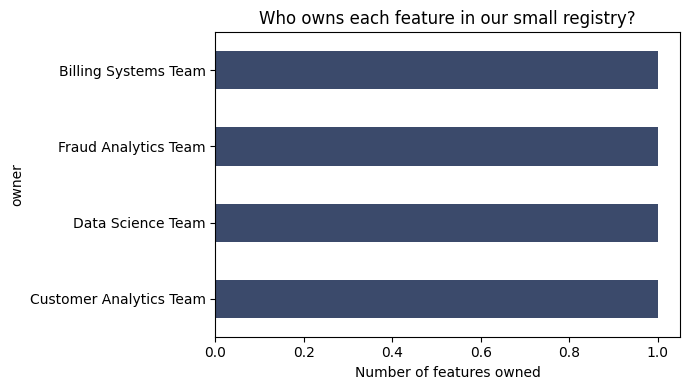

In [3]:
import matplotlib.pyplot as plt

owner_counts = feature_registry["owner"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
owner_counts.plot(kind="barh", ax=ax, color="#3B4A6B")
ax.set_title("Who owns each feature in our small registry?")
ax.set_xlabel("Number of features owned")
plt.tight_layout()
plt.show()

**What should you notice?** Even in this tiny 4-feature registry, ownership is already split
across THREE different teams. At real company scale, with hundreds of features, this
fragmentation is exactly why "who do I ask about this feature" becomes a genuinely hard
question without a registry — and exactly why writing the owner down, feature by feature, pays
for itself almost immediately.

## Industry Case Study

**Banking — model risk management audits.** Banks are legally required to demonstrate, for
every model used in a lending decision, exactly what data went into it, where that data came
from, and whether it was appropriate to use. When a regulator asks "show me every feature used
in this credit model, and prove none of them are illegal to use for lending" (age, certain
demographic proxies, etc.), a bank WITHOUT feature documentation has to reconstruct this
information under time pressure — often taking weeks and involving multiple teams. A bank WITH
a feature registry can answer the same question in minutes, by querying the registry directly.

```
RAW DATA               FEATURE                    MODEL          BUSINESS DECISION
---------               -------                    -----          ------------------
credit bureau     -->   credit_score          -->  predicts  -->  approve / decline
records                 (documented: source,        default        + audit trail showing
                         owner, allowed_for_                        exactly which features
                         training=True)                              were used and why
```

This is precisely why "feature documentation" isn't a nice-to-have in regulated industries —
it's closer to a legal requirement, and the discipline of writing feature cards (as we did
above) is the foundation that makes audits fast instead of a crisis.

## What Can Go Wrong?

**Mistake 1 — Documentation drifts out of sync with the actual code**

- **Problem:** someone updates how a feature is calculated but forgets to update its card.
- **Why it happens:** documentation lives in a different place than the code, with no
  enforced link between them.
- **Example:** a feature card says "calculated using 30 days of history," but the underlying
  code was quietly changed to use 60 days, and nobody updated the card.
- **How to detect it:** periodically spot-check a feature's actual code against its
  documented transformation.
- **How to fix it:** where possible, generate documentation FROM the code (e.g., docstrings on
  a feature transformer class) rather than maintaining it as a totally separate document.

**Mistake 2 — No owner listed, or an owner who has left the team**

- **Problem:** nobody knows who to ask when a feature looks wrong or needs updating.
- **Why it happens:** ownership isn't recorded at all, or is recorded once and never revisited
  as people change roles.
- **How to detect it:** check whether any feature's `owner` field is blank, or belongs to
  someone no longer on the team.
- **How to fix it:** treat ownership as a TEAM responsibility (e.g., "Fraud Analytics Team"),
  not an individual person's, so it survives personnel changes.

**Mistake 3 — Treating "documented" as the same as "safe to use"**

- **Problem:** a feature can be perfectly well-documented and STILL be leaked, biased, or
  otherwise inappropriate to use.
- **Why it happens:** documentation and governance review are two different steps — writing
  down what a feature does doesn't automatically confirm it's SAFE.
- **Example:** `final_bill_amount` in our registry above is fully documented — and explicitly
  marked `allowed_for_training = False`, precisely because documentation revealed the problem,
  not hid it.
- **How to fix it:** always include an explicit `allowed_for_training` (or equivalent
  governance) field, reviewed separately from the descriptive metadata.

## Mini Exercise

**Try this yourself before looking at the solution.**

You're handed a feature called `total_lifetime_purchases` with NO documentation. Write out
what a complete Feature Card for it SHOULD contain, based on reasonable assumptions — then list
the 3 most important questions you'd still need to ask the original creator (if you could find
them) to confirm your assumptions.

## Exercise Solution

**A reasonable draft Feature Card:**

```
Feature: total_lifetime_purchases
Definition: Total number of purchases a customer has ever made
Source: (assumed) transactions table, counted per customer_id
Transformation: (assumed) COUNT(transaction_id) grouped by customer_id, no date filter
Freshness: (unknown -- needs confirmation)
Owner: (unknown -- needs confirmation)
Allowed for training: (needs governance review before assuming yes)
```

**The 3 most important questions to confirm:**
1. **Is this truly unbounded (all-time), or is there an implicit cutoff** (e.g., only purchases
   in the current loyalty program era)? This changes what the number actually represents.
2. **How often is it recalculated?** A stale, rarely-updated "lifetime" count could be badly out
   of date for an actively purchasing customer.
3. **Does "purchases" include refunded/cancelled orders?** This single definitional detail could
   change the number significantly and isn't obvious from the name alone.

This exercise is exactly why undocumented features are risky: even a "simple-sounding" feature
name like `total_lifetime_purchases` hides several genuine ambiguities that only the original
creator (or good documentation) can resolve with confidence.

## Interview Questions

**1. (Conceptual) Why does a feature need documentation if the code that computes it already
exists?**
> Code shows HOW something is computed but rarely explains WHY, what business concept it
> represents, who's responsible for it, or whether it's safe to reuse elsewhere — questions a
> new team member or auditor needs answered quickly, without reading and reverse-engineering
> the implementation.

**2. (Practical) What's the minimum set of fields a feature card should have?**
> A description/business definition, its data source, the transformation logic, an owner, a
> freshness/update cadence, and an explicit flag for whether it's approved for training use.

**3. (Practical) Why should feature ownership be assigned to a TEAM rather than an individual?**
> Individuals change roles or leave companies; a team-level owner survives personnel turnover
> and ensures there's always someone accountable for the feature.

**4. (Scenario) You find a feature that's fully documented but marked `allowed_for_training =
False`. What does that tell you?**
> That someone already identified a problem with using it (e.g., leakage, bias, or a
> regulatory restriction) and recorded that decision — documentation and safety are separate
> concerns, and this feature is a case where documentation SURFACED a governance issue rather
> than concealing it.

**5. (Conceptual) What's the risk of documentation drifting out of sync with the actual code?**
> Anyone relying on the documentation (rather than reading the code) could form an incorrect
> understanding of what a feature actually measures, leading to misuse or false confidence in
> results.

**6. (Practical) Why might real-time features (like `transaction_velocity_24h`) need different
governance considerations than daily-batch features?**
> Real-time features require live infrastructure to compute correctly at prediction time, so
> their metadata should also capture serving requirements (e.g., what system computes it, how
> fresh it truly is at inference time) beyond what a daily-refreshed feature needs.

**7. (Scenario) A regulator asks your bank to prove no illegal feature was used in a lending
model. How does a feature registry help you respond?**
> You can query the registry directly for every feature's source, definition, and
> `allowed_for_training` status, producing an audit trail in minutes instead of reconstructing
> the information from scratch across multiple teams and codebases.

**8. (Conceptual) Is a feature registry the same thing as a Feature Store (next chapter)?**
> No — a registry is documentation/metadata (what a feature means, who owns it, is it
> allowed). A Feature Store (next chapter) is the actual infrastructure that COMPUTES, STORES,
> and SERVES feature values for training and real-time inference. Many real feature stores
> include a registry as one part of their functionality, but documentation alone doesn't
> require the infrastructure.

## Assignment (30-60 minutes)

Using the `transactions.csv` and `customers.csv` data from this chapter:

1. Pick TWO features from the Business Features chapter that are NOT already in the registry
   above (e.g., `unusual_amount`, `declining_activity`, `support_call_frequency`).
2. Write a complete Feature Card for each, following the same format as this notebook.
3. For each, explicitly answer: is it allowed for training? Justify your answer using the
   reasoning from the Data Leakage chapter (could this feature have existed at prediction
   time?).
4. Add both to a registry DataFrame, alongside the 4 features already in this notebook.

## Key Takeaways

- Undocumented features cost real time and create real risk — the fix (a feature card) takes
  only a few sentences per feature.
- A minimal feature registry needs: description, source, transformation, owner, freshness, and
  an explicit training-allowed flag.
- Documentation and safety review are SEPARATE concerns — a feature can be fully documented and
  still be marked unsafe to use.
- Assign ownership to teams, not individuals, so accountability survives personnel changes.
- In regulated industries, feature documentation is closer to a legal requirement than a
  nice-to-have — it's what makes audits take minutes instead of weeks.
- A feature registry is documentation; a Feature Store (next chapter) is the infrastructure
  that actually serves the feature values — related but distinct concepts.

## Final Challenge

Your company is about to launch a NEW fraud detection model using 15 features pulled from 4
different source systems (transactions, customer accounts, device logs, and a third-party
credit bureau feed). Using everything from this chapter:

1. Design the column structure for a feature registry that would work for all 15 features
   across all 4 source systems.
2. Identify which fields in your registry would be MOST important to get right before this
   model goes live in a regulated context, and why.
3. Propose one process (not a specific tool) your team could adopt to prevent documentation
   from drifting out of sync with the actual feature code over time.